In [1]:
import pandas as pd
import random
import pprint
import sklearn.datasets as datasets
from data_consistency_checker import DataConsistencyChecker

In [2]:
# This notebook provides an example of working with a sample toy
# dataset available through sklearn.

In [3]:
pd.options.display.max_columns = 1000
pd.options.display.max_colwidth = 1000
pd.options.display.max_rows = 1000
pd.options.display.width = 10000

In [4]:
from IPython.display import display, HTML
display(HTML("<style>div.output_area pre {white-space: pre;}</style>"))

# Breast cancer

In [5]:
# Load the data
data = datasets.load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)

# Run DataConsistencyChecker with default parameters, other than verbose=0
# to skip printing the test IDs as the tests exectute. 
dc = DataConsistencyChecker(verbose=0)  
dc.init_data(df)
_ = dc.check_data_quality()


Data consistency check complete.
Analysed 569 rows, 30 columns
Executed 158 tests.

Patterns without Exceptions:
Found 157 patterns without exceptions
15 tests (9.49% of tests) identified at least one pattern without exceptions each. 
By default some patterns are not listed in calls to display_detailed_results().

Patterns with Exceptions:
Found 46 patterns with exceptions
10 tests (6.33% of tests) flagged at least one exception each.
Flagged 29 row(s) with at least one exception.
Flagged 29 column(s) with at least one exception.


In [6]:
# Get an overview of every test. For each, we get both the number of patterns found
# and the number of exceptions found. It may be informative where no patterns were
# found, if they would be expected. Other APIs can examine intances of these more
# closely. 

dc.summarize_patterns_and_exceptions()

,Test ID,Number Patterns without Exceptions,Number Patterns with Exceptions
0,MISSING_VALUES,30,
1,POSITIVE,30,
2,NUMBER_DECIMALS,26,3
3,UNUSUAL_ORDER_MAGNITUDE,3,1
4,FEW_NEIGHBORS,,6
5,VERY_LARGE,,5
6,NON_ZERO,24,
7,LESS_THAN_ONE,16,1
8,GREATER_THAN_ONE,9,
9,LARGER_DIFF_RANGE,3,13


In [7]:
# Get a summary of which patterns were present in which columns. It
# may be as informative where the pattern is not present. 

dc.summarize_patterns_by_test_and_feature()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
Test ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
MISSING_VALUES,✔,✔,✔,✔,✔,✔,✔,✔,✔,✔,✔,✔,✔,✔,✔,✔,✔,✔,✔,✔,✔,✔,✔,✔,✔,✔,✔,✔,✔,✔
POSITIVE,✔,✔,✔,✔,✔,✔,✔,✔,✔,✔,✔,✔,✔,✔,✔,✔,✔,✔,✔,✔,✔,✔,✔,✔,✔,✔,✔,✔,✔,✔
NUMBER_DECIMALS,✔,✔,✔,✔,✔,✔,,✔,✔,✔,✔,✔,✔,✔,✔,✔,,✔,✔,✔,✔,✔,✔,✔,✔,✔,,,✔,✔
UNUSUAL_ORDER_MAGNITUDE,✔,,✔,,,,,,,,,,,,,,,,,,,,✔,,,,,,,
NON_ZERO,✔,✔,✔,✔,✔,✔,,,✔,✔,✔,✔,✔,✔,✔,✔,,,✔,✔,✔,✔,✔,✔,✔,✔,,,✔,✔
LESS_THAN_ONE,,,,,✔,✔,✔,✔,✔,✔,,,,,✔,✔,✔,✔,✔,✔,,,,,✔,,,✔,✔,✔
GREATER_THAN_ONE,✔,✔,✔,✔,,,,,,,,,,✔,,,,,,,✔,✔,✔,✔,,,,,,
LARGER_DIFF_RANGE,✔,✔,✔,✔,✔,✔,✔,✔,✔,✔,✔,✔,✔,✔,✔,✔,✔,✔,,✔,✔,✔,✔,✔,✔,✔,✔,✔,✔,✔
MUCH_LARGER,✔,,,✔,,,,,,,✔,,,✔,,,,,,,✔,,,✔,,,,,,


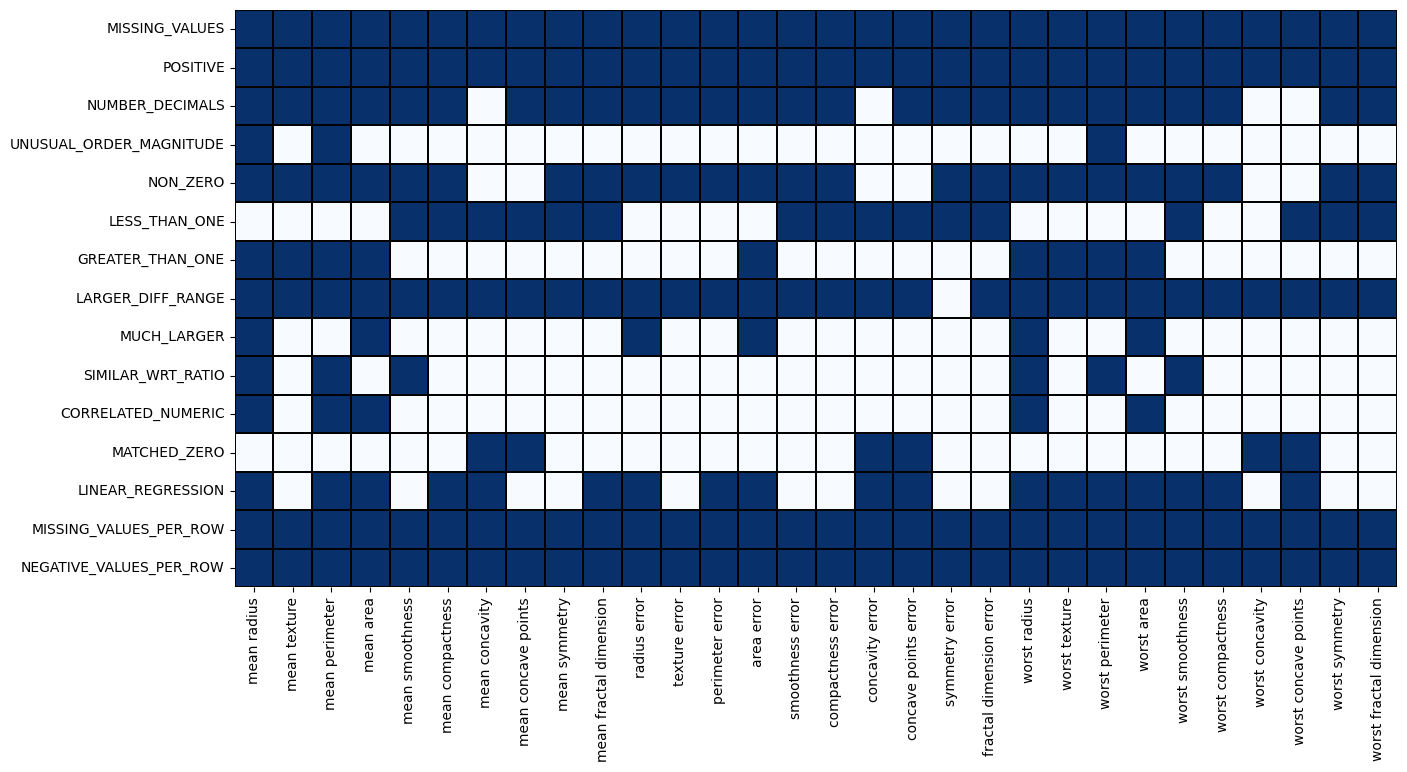

In [8]:
# View the above in the form of a heatmap. In practice, one or the other
# format would be used and not both. 

_ = dc.summarize_patterns_by_test_and_feature(heatmap=True)

In [9]:
# List each pattern found in more detail. This lists every pattern found, and for each,
# the Test ID, the column or set of columns where the pattern was found, and a 
# description of the pattern. This lists only patterns that have no exceptions. 

dc.get_patterns_list()

Some&nbsp;patterns&nbsp;not&nbsp;shown.&nbsp;Set&nbsp;show_short_list_only&nbsp;to&nbsp;False&nbsp;to&nbsp;see&nbsp;additional&nbsp;patterns.

,Test ID,Column(s),Description of Pattern,Pattern ID
113,LESS_THAN_ONE,mean smoothness,"The column consistently contains values between -1.0, and 1.0 (inclusive)",113
114,LESS_THAN_ONE,mean compactness,"The column consistently contains values between -1.0, and 1.0 (inclusive)",114
115,LESS_THAN_ONE,mean concavity,"The column consistently contains values between -1.0, and 1.0 (inclusive)",115
116,LESS_THAN_ONE,mean concave points,"The column consistently contains values between -1.0, and 1.0 (inclusive)",116
117,LESS_THAN_ONE,mean symmetry,"The column consistently contains values between -1.0, and 1.0 (inclusive)",117
118,LESS_THAN_ONE,mean fractal dimension,"The column consistently contains values between -1.0, and 1.0 (inclusive)",118
119,LESS_THAN_ONE,smoothness error,"The column consistently contains values between -1.0, and 1.0 (inclusive)",119
120,LESS_THAN_ONE,compactness error,"The column consistently contains values between -1.0, and 1.0 (inclusive)",120
121,LESS_THAN_ONE,concavity error,"The column consistently contains values between -1.0, and 1.0 (inclusive)",121
122,LESS_THAN_ONE,concave points error,"The column consistently contains values between -1.0, and 1.0 (inclusive)",122


In [10]:
# This provides a similar report, except for the patterns that have exceptions. 
# Here, the number of exceptions found, as well as Issue ID are also included.
# Issue ID may be used in calls to display_detailed_results() to focus on this
# specific issue if desired. 

dc.get_exceptions_list()

,Test ID,Column(s),Description of Pattern,Number of Exceptions,Issue ID
0,NUMBER_DECIMALS,mean concavity,"The column contains values consistently with 0, 2, 3, 4, 5 decimals, with exceptions.",1,0
1,NUMBER_DECIMALS,concavity error,"The column contains values consistently with 0, 2, 3, 4, 5 decimals, with exceptions.",2,1
2,NUMBER_DECIMALS,worst concave points,"The column contains values consistently with 0, 2, 3, 4 decimals, with exceptions.",2,2
3,UNUSUAL_ORDER_MAGNITUDE,area error,This test checks for values of an unusual order of magnitude. Each value is described in terms of it...,2,3
4,FEW_NEIGHBORS,mean area,The test marked any values more than 235.750 away from both the next smallest and next largest value...,1,4
5,FEW_NEIGHBORS,radius error,The test marked any values more than 0.276 away from both the next smallest and next largest values ...,1,5
6,FEW_NEIGHBORS,perimeter error,The test marked any values more than 2.122 away from both the next smallest and next largest values ...,1,6
7,FEW_NEIGHBORS,concavity error,The test marked any values more than 0.040 away from both the next smallest and next largest values ...,1,7
8,FEW_NEIGHBORS,fractal dimension error,The test marked any values more than 0.003 away from both the next smallest and next largest values ...,1,8
9,FEW_NEIGHBORS,worst fractal dimension,The test marked any values more than 0.015 away from both the next smallest and next largest values ...,1,9


In [11]:
# summarize_exceptions_by_test() gives a sense of which tests are 
# identifying the most exceptions in this dataset. This may indicate
# where more attention should be focussed, or in other cases, where
# the most issues should be cleared to reduce noise, if any may be
# deemed insignificant, or already understood. 

dc.summarize_exceptions_by_test()

,Number of Columns Flagged At Least Once,Number of Rows Flagged At Least Once,Number of Issues Total
Test ID,,,
NUMBER_DECIMALS,3,4,5
UNUSUAL_ORDER_MAGNITUDE,1,2,2
FEW_NEIGHBORS,6,5,6
VERY_LARGE,5,7,9
LESS_THAN_ONE,1,1,1
LARGER_DIFF_RANGE,13,9,19
LARGER_SAME_RANGE,3,2,6
SIMILAR_WRT_RATIO,3,5,5
RARE_COMBINATION,10,8,13


In [12]:
# display_most_flagged_rows() lists the rows with the highest scores, highlights
# the cells that are flagged at least once, and indicates which tests flagged
# these cells. 

dc.display_most_flagged_rows()

**Row: 212 — Final Score: 13**

,Test ID,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,,28.110000,18.470000,188.500000,2499.000000,0.114200,0.151600,0.320100,0.159500,0.164800,0.055250,2.873000,1.476000,21.980000,525.600000,0.013450,0.027720,0.063890,0.014070,0.047830,0.004476,28.110000,18.470000,188.500000,2499.000000,0.114200,0.151600,0.320100,0.159500,0.164800,0.055250
1,UNUSUAL_ORDER_MAGNITUDE,,,,,,,,,,,,,,✔,,,,,,,,,,,,,,,,
2,LARGER_DIFF_RANGE,,✔,,,✔,✔,,✔,✔,✔,,,,,,,,,,,,✔,,,✔,✔,,,✔,✔
3,LARGER_SAME_RANGE,✔,,✔,✔,,,,,,,,,,,,,,,,,✔,,✔,✔,,,,,,
4,SIMILAR_WRT_RATIO,,,,,✔,,,,,,,,,,,,,,,,,,,,,,,,,✔
5,RARE_COMBINATION,,,,,,,✔,,,,,,,,,,,,✔,,,,,,,,,,,
6,LINEAR_REGRESSION,✔,,✔,✔,,,✔,,,✔,✔,,✔,,,✔,,,,,,,,✔,,,,✔,,


**Row: 38 — Final Score: 8**

,Test ID,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,,14.990000,25.200000,95.540000,698.800000,0.093870,0.051310,0.023980,0.028990,0.156500,0.055040,1.214000,2.188000,8.077000,106.000000,0.006883,0.010940,0.018180,0.019170,0.007882,0.001754,14.990000,25.200000,95.540000,698.800000,0.093870,0.051310,0.023980,0.028990,0.156500,0.055040
1,LARGER_DIFF_RANGE,,✔,,,✔,✔,,,✔,✔,,,,,,,,,,,,✔,,,✔,✔,,,✔,✔
2,LARGER_SAME_RANGE,✔,,✔,✔,,,,,,,,,,,,,,,,,✔,,✔,✔,,,,,,


**Row: 9 — Final Score: 5**

...

,Test ID,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,,27.220000,21.870000,182.100000,2250.000000,0.109400,0.191400,0.287100,0.187800,0.180000,0.057700,0.836100,1.481000,5.820000,128.700000,0.004631,0.025370,0.031090,0.012410,0.015750,0.002747,33.120000,32.850000,220.800000,3216.000000,0.147200,0.403400,0.534000,0.268800,0.285600,0.080820
1,FEW_NEIGHBORS,,,,✔,,,,,,,,,,,,,,,,,,,,,,,,,,
2,LARGER_DIFF_RANGE,,,,,,,,✔,✔,,,,,,,,,,,,,,,,,,,,,


**Row: 82 — Final Score: 2**

,Test ID,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,,25.220000,24.910000,171.500000,1878.000000,0.106300,0.266500,0.333900,0.184500,0.182900,0.067820,0.897300,1.474000,7.382000,120.000000,0.008166,0.056930,0.057300,0.020300,0.010650,0.005893,30.000000,33.620000,211.700000,2562.000000,0.157300,0.607600,0.647600,0.286700,0.235500,0.105100
1,LARGER_DIFF_RANGE,,,,,,✔,,✔,✔,,,,,,,,,,,,,,,,,,,,✔,


**Row: 152 — Final Score: 2**

,Test ID,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,,9.731000,15.340000,63.780000,300.200000,0.107200,0.159900,0.410800,0.078570,0.254800,0.092960,0.824500,2.664000,4.073000,49.850000,0.010970,0.095860,0.396000,0.052790,0.035460,0.029840,11.020000,19.490000,71.040000,380.500000,0.129200,0.277200,0.821600,0.157100,0.310800,0.125900
1,VERY_LARGE,,,,,,,,,,,,,,,,,,✔,,,,,,,,,,,,
2,LARGER_DIFF_RANGE,,,,,,,,,,,,,,,,,✔,,,,,,,,,✔,,,,


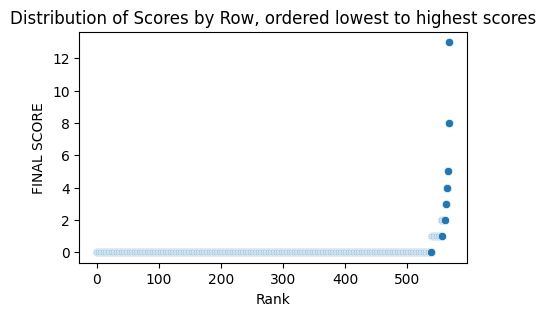

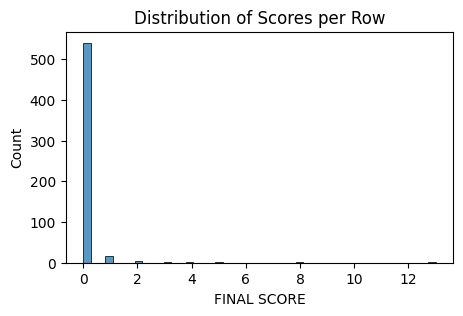

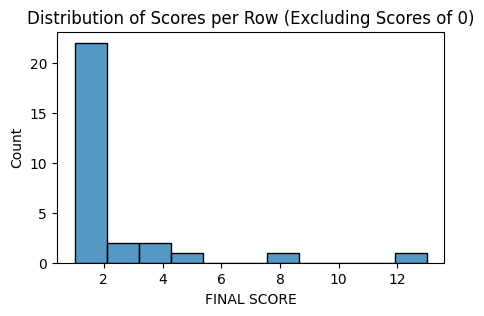

In [13]:
# Get a breakdown of the distribution of scores. This can assist,
# for example, indetermining if there is a cut-off if users wish 
# to set a binary flag distinguishing inliers from outliers. 

dc.plot_final_scores_distribution_by_row()

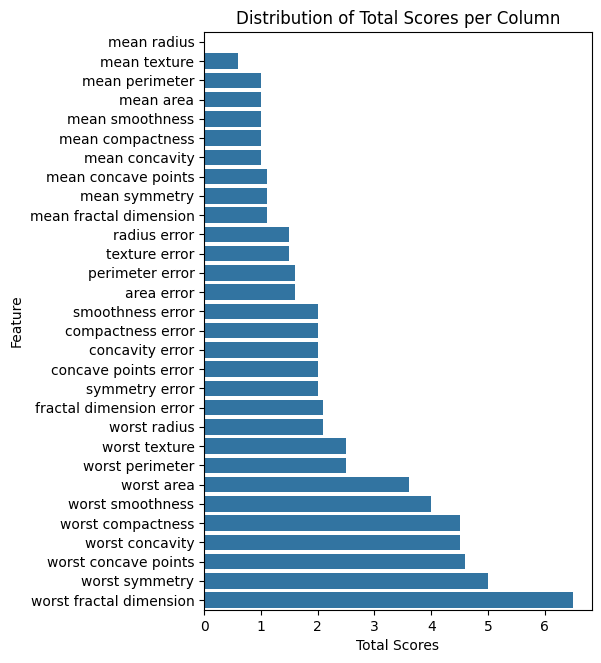

In [14]:
# Examine which features tend to be flagged the most

dc.plot_final_scores_distribution_by_feature()

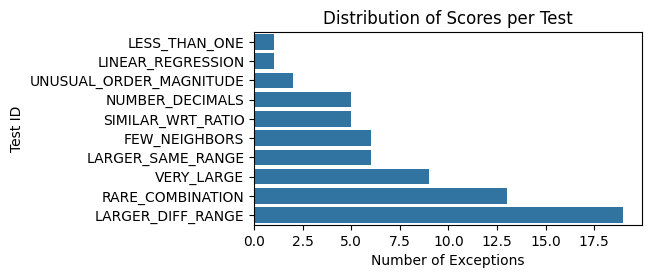

In [15]:
# Examine which tests tend to flag the most

dc.plot_final_scores_distribution_by_test()

In [16]:
# Look at the 'NUMBER_DECIMALS' test more closely, listing all 
# patterns with exceptions.

dc.display_detailed_results(test_id_list=['NUMBER_DECIMALS'], show_patterns=False)

Not&nbsp;displaying&nbsp;patterns&nbsp;without&nbsp;exceptions&nbsp;for&nbsp;NUMBER_DECIMALS.&nbsp;This&nbsp;test&nbsp;is&nbsp;not&nbsp;in&nbsp;the&nbsp;short&nbsp;list&nbsp;and&nbsp;the&nbsp;parameter&nbsp;show_short_list_only&nbsp;was&nbsp;set&nbsp;to&nbsp;True

### Columns(s): mean concavity

**Issue&nbsp;ID**:&nbsp;0

A&nbsp;strong&nbsp;pattern,&nbsp;and&nbsp;exceptions&nbsp;to&nbsp;the&nbsp;pattern,&nbsp;were&nbsp;found.<br>

**Description**:&nbsp;The&nbsp;column&nbsp;contains&nbsp;values&nbsp;consistently&nbsp;with&nbsp;0,&nbsp;2,&nbsp;3,&nbsp;4,&nbsp;5&nbsp;decimals,&nbsp;with&nbsp;exceptions.

...

**Number&nbsp;of&nbsp;exceptions**:&nbsp;2&nbsp;(0.3515%&nbsp;of&nbsp;rows)

**Examples&nbsp;of&nbsp;values&nbsp;NOT&nbsp;flagged**:

,worst concave points,Number decimals
46,0.02564,5
52,0.06296,5
81,0.1708,4
101,0.0,0
102,0.07431,5
106,0.1218,4
111,0.1105,4
172,0.1827,4
173,0.04306,5
324,0.05556,5


**Flagged&nbsp;values**:

,worst concave points,Number decimals
178,0.009259,6
285,0.008772,6


In [17]:
# Look at Issue 52 more closely

dc.display_detailed_results(issue_id_list=[52])

....................................................................................................

### SIMILAR_WRT_RATIO

### Columns(s): "mean fractal dimension" AND "worst fractal dimension"

**Issue&nbsp;ID**:&nbsp;34

A&nbsp;strong&nbsp;pattern,&nbsp;and&nbsp;exceptions&nbsp;to&nbsp;the&nbsp;pattern,&nbsp;were&nbsp;found.<br>

...

**Number&nbsp;of&nbsp;exceptions**:&nbsp;2&nbsp;(0.3515%&nbsp;of&nbsp;rows)

**Examples&nbsp;of&nbsp;values&nbsp;NOT&nbsp;flagged**:

,mean fractal dimension,worst fractal dimension,RATIO
6,0.057420,0.083680,0.686185
35,0.056560,0.086330,0.655160
53,0.063100,0.079870,0.790034
73,0.065660,0.103000,0.637476
116,0.071630,0.077220,0.927609
183,0.062170,0.074270,0.837081
194,0.066720,0.087010,0.766808
207,0.052230,0.064690,0.807389
224,0.056740,0.076230,0.744326
242,0.076690,0.129700,0.591288


**Flagged&nbsp;values**:

,mean fractal dimension,worst fractal dimension,RATIO
9,0.082430,0.207500,0.397253
72,0.064870,0.133900,0.484466


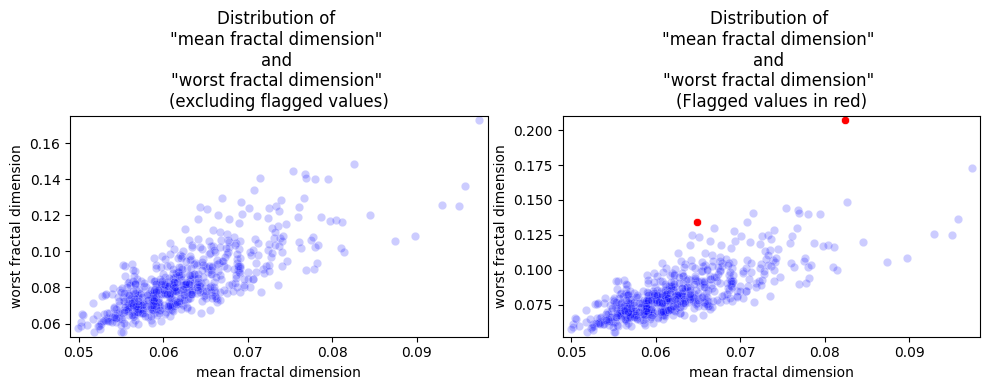

In [18]:
# Look at issue 34 more closely

dc.display_detailed_results(issue_id_list=[34])

### Columns(s): "mean radius" AND "worst radius"

Pattern&nbsp;found&nbsp;(without&nbsp;exceptions)

**Description**:&nbsp;"mean&nbsp;radius"&nbsp;and&nbsp;"worst&nbsp;radius"&nbsp;have&nbsp;consistently&nbsp;similar&nbsp;values&nbsp;in&nbsp;terms&nbsp;of&nbsp;their&nbsp;ratio&nbsp;(with&nbsp;0&nbsp;rows&nbsp;having&nbsp;identical&nbsp;values).&nbsp;Rows&nbsp;with&nbsp;values&nbsp;of&nbsp;zero&nbsp;are&nbsp;not&nbsp;tested.

**Examples**:

,mean radius,worst radius,RATIO
19,13.540000,15.110000,0.896095
102,12.180000,13.340000,0.913043
159,10.900000,12.360000,0.881877
170,12.320000,13.500000,0.912593
267,13.590000,14.800000,0.918243
275,11.890000,12.400000,0.958871
311,14.610000,16.460000,0.887606
399,11.800000,13.450000,0.877323
413,14.990000,16.760000,0.894391
455,13.380000,15.050000,0.889037


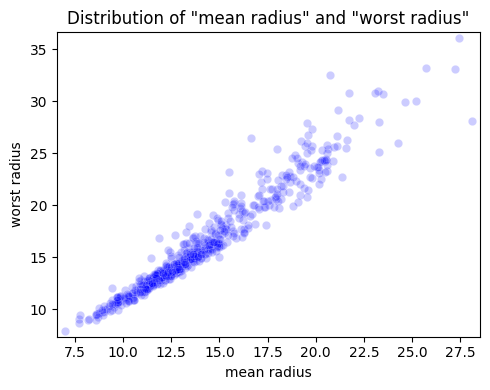

### Columns(s): "mean perimeter" AND "worst perimeter"

Pattern&nbsp;found&nbsp;(without&nbsp;exceptions)

**Description**:&nbsp;"mean&nbsp;perimeter"&nbsp;and&nbsp;"worst&nbsp;perimeter"&nbsp;have&nbsp;consistently&nbsp;similar&nbsp;values&nbsp;in&nbsp;terms&nbsp;of&nbsp;their&nbsp;ratio&nbsp;(with&nbsp;0&nbsp;rows&nbsp;having&nbsp;identical&nbsp;values).&nbsp;Rows&nbsp;with&nbsp;values&nbsp;of&nbsp;zero&nbsp;are&nbsp;not&nbsp;tested.

**Examples**:

,mean perimeter,worst perimeter,RATIO
1,132.900000,158.800000,0.836902
31,77.930000,119.400000,0.652680
54,97.260000,117.700000,0.826338
128,99.580000,105.900000,0.940321
193,81.150000,101.700000,0.797935
410,72.490000,85.070000,0.852122
437,89.780000,101.200000,0.887154
438,88.680000,100.900000,0.878890
486,94.210000,106.000000,0.888774
494,84.060000,95.290000,0.882149


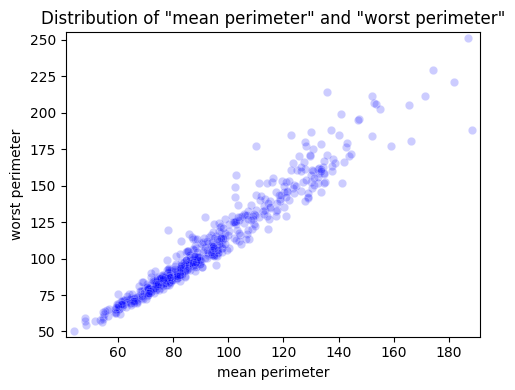

### Columns(s): "mean smoothness" AND "worst smoothness"

Pattern&nbsp;found&nbsp;(without&nbsp;exceptions)

**Description**:&nbsp;"mean&nbsp;smoothness"&nbsp;and&nbsp;"worst&nbsp;smoothness"&nbsp;have&nbsp;consistently&nbsp;similar&nbsp;values&nbsp;in&nbsp;terms&nbsp;of&nbsp;their&nbsp;ratio&nbsp;(with&nbsp;0&nbsp;rows&nbsp;having&nbsp;identical&nbsp;values).&nbsp;Rows&nbsp;with&nbsp;values&nbsp;of&nbsp;zero&nbsp;are&nbsp;not&nbsp;tested.

**Examples**:

,mean smoothness,worst smoothness,RATIO
20,0.107500,0.131200,0.819360
23,0.094280,0.140100,0.672948
60,0.113400,0.127500,0.889412
133,0.094620,0.122300,0.773671
140,0.092500,0.123400,0.749595
169,0.098550,0.121600,0.810444
177,0.098310,0.141500,0.694770
242,0.095920,0.134700,0.712101
268,0.094250,0.125600,0.750398
483,0.099500,0.119900,0.829858


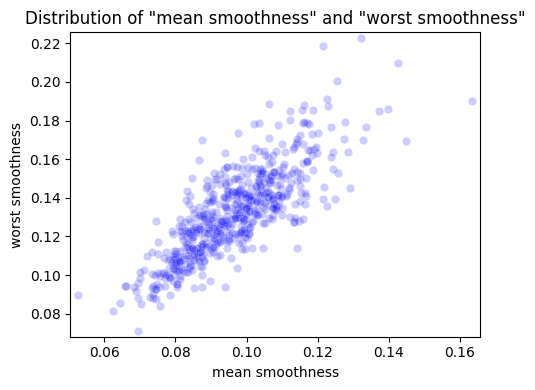

### Columns(s): "mean texture" AND "worst texture"

**Issue&nbsp;ID**:&nbsp;32

A&nbsp;strong&nbsp;pattern,&nbsp;and&nbsp;exceptions&nbsp;to&nbsp;the&nbsp;pattern,&nbsp;were&nbsp;found.<br>

**Description**:&nbsp;"mean&nbsp;texture"&nbsp;and&nbsp;"worst&nbsp;texture"&nbsp;have&nbsp;consistently&nbsp;similar&nbsp;values&nbsp;in&nbsp;terms&nbsp;of&nbsp;their&nbsp;ratio&nbsp;(with&nbsp;0<br>rows&nbsp;having&nbsp;identical&nbsp;values).&nbsp;Rows&nbsp;with&nbsp;values&nbsp;of&nbsp;zero&nbsp;are&nbsp;not&nbsp;tested,&nbsp;with&nbsp;exceptions.

**Number&nbsp;of&nbsp;exceptions**:&nbsp;1&nbsp;(0.1757%&nbsp;of&nbsp;rows)

**Examples&nbsp;of&nbsp;values&nbsp;NOT&nbsp;flagged**:

,mean texture,worst texture,RATIO
6,19.980000,27.660000,0.722343
7,20.830000,28.140000,0.740227
8,21.820000,30.730000,0.710055
27,20.250000,27.260000,0.742847
42,24.810000,33.170000,0.747965
125,17.210000,23.580000,0.729856
157,19.460000,28.070000,0.693267
172,11.890000,17.040000,0.697770
183,14.920000,17.700000,0.842938
194,23.210000,27.780000,0.835493


**Flagged&nbsp;values**:

,mean texture,worst texture,RATIO
410,17.570000,36.320000,0.483756


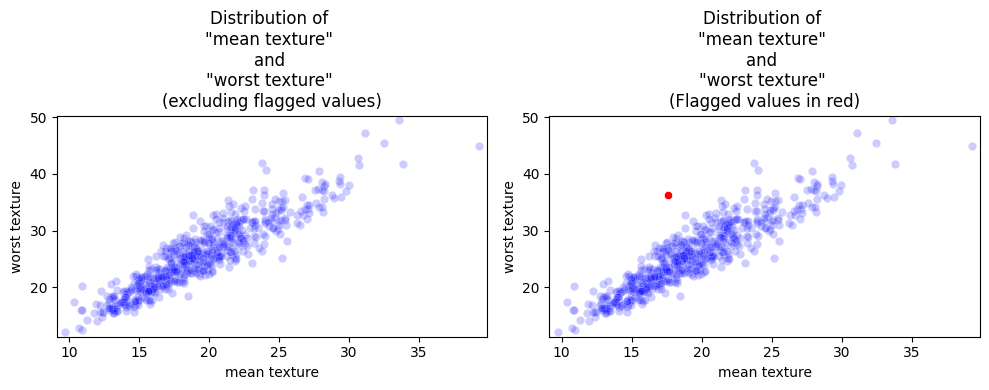

### Columns(s): "mean smoothness" AND "worst fractal dimension"

**Issue&nbsp;ID**:&nbsp;33

A&nbsp;strong&nbsp;pattern,&nbsp;and&nbsp;exceptions&nbsp;to&nbsp;the&nbsp;pattern,&nbsp;were&nbsp;found.<br>

**Description**:&nbsp;"mean&nbsp;smoothness"&nbsp;and&nbsp;"worst&nbsp;fractal&nbsp;dimension"&nbsp;have&nbsp;consistently&nbsp;similar&nbsp;values&nbsp;in&nbsp;terms&nbsp;of&nbsp;their<br>ratio&nbsp;(with&nbsp;0&nbsp;rows&nbsp;having&nbsp;identical&nbsp;values).&nbsp;Rows&nbsp;with&nbsp;values&nbsp;of&nbsp;zero&nbsp;are&nbsp;not&nbsp;tested,&nbsp;with<br>exceptions.

**Number&nbsp;of&nbsp;exceptions**:&nbsp;2&nbsp;(0.3515%&nbsp;of&nbsp;rows)

**Examples&nbsp;of&nbsp;values&nbsp;NOT&nbsp;flagged**:

,mean smoothness,worst fractal dimension,RATIO
6,0.094630,0.083680,1.130856
35,0.096100,0.086330,1.113170
53,0.114800,0.079870,1.437336
73,0.100700,0.103000,0.977670
116,0.094620,0.077220,1.225330
183,0.090590,0.074270,1.219739
194,0.104400,0.087010,1.199862
207,0.087720,0.064690,1.356006
224,0.084450,0.076230,1.107832
242,0.095920,0.129700,0.739553


**Flagged&nbsp;values**:

,mean smoothness,worst fractal dimension,RATIO
212,0.114200,0.055250,2.066968
275,0.122500,0.060330,2.030499


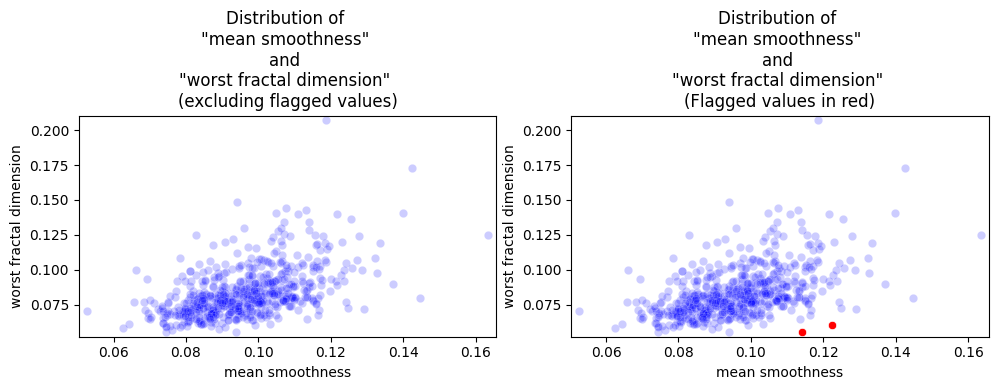

### Columns(s): "mean fractal dimension" AND "worst fractal dimension"

**Issue&nbsp;ID**:&nbsp;34

A&nbsp;strong&nbsp;pattern,&nbsp;and&nbsp;exceptions&nbsp;to&nbsp;the&nbsp;pattern,&nbsp;were&nbsp;found.<br>

**Description**:&nbsp;"mean&nbsp;fractal&nbsp;dimension"&nbsp;and&nbsp;"worst&nbsp;fractal&nbsp;dimension"&nbsp;have&nbsp;consistently&nbsp;similar&nbsp;values&nbsp;in&nbsp;terms&nbsp;of<br>their&nbsp;ratio&nbsp;(with&nbsp;0&nbsp;rows&nbsp;having&nbsp;identical&nbsp;values).&nbsp;Rows&nbsp;with&nbsp;values&nbsp;of&nbsp;zero&nbsp;are&nbsp;not&nbsp;tested,&nbsp;with<br>exceptions.

**Number&nbsp;of&nbsp;exceptions**:&nbsp;2&nbsp;(0.3515%&nbsp;of&nbsp;rows)

**Examples&nbsp;of&nbsp;values&nbsp;NOT&nbsp;flagged**:

,mean fractal dimension,worst fractal dimension,RATIO
6,0.057420,0.083680,0.686185
35,0.056560,0.086330,0.655160
53,0.063100,0.079870,0.790034
73,0.065660,0.103000,0.637476
116,0.071630,0.077220,0.927609
183,0.062170,0.074270,0.837081
194,0.066720,0.087010,0.766808
207,0.052230,0.064690,0.807389
224,0.056740,0.076230,0.744326
242,0.076690,0.129700,0.591288


**Flagged&nbsp;values**:

,mean fractal dimension,worst fractal dimension,RATIO
9,0.082430,0.207500,0.397253
72,0.064870,0.133900,0.484466


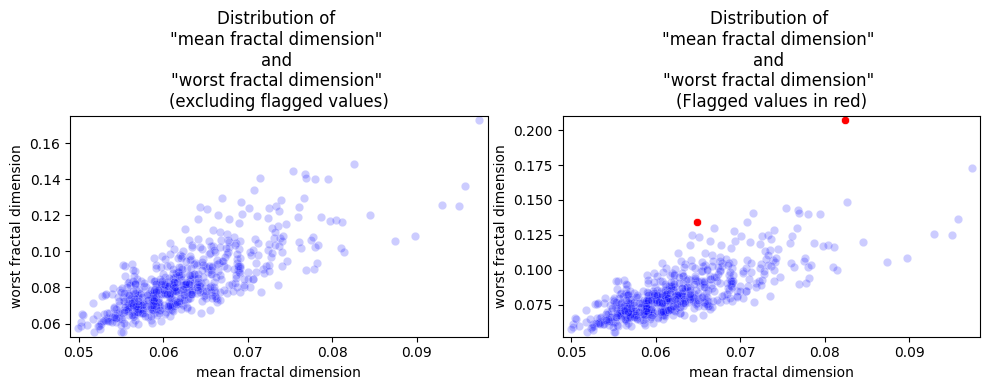

In [19]:
# Look at the SIMILAR_WRT_RATIO test more closely. This found several
# patterns without and several with exceptions. 

dc.display_detailed_results(test_id_list=['SIMILAR_WRT_RATIO'])